In [5]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
from scipy.stats import spearmanr,pearsonr
import nitools as nt
import pandas as pd


# define atlas for data used and ROI mask dir

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


# Make ROI

In [4]:
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig


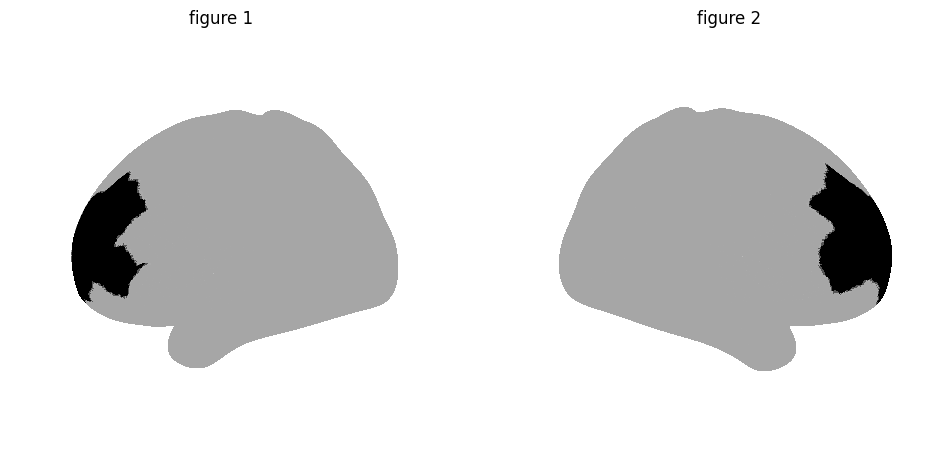

In [5]:
# roi (prefrontal cortex)
ROI_cortex = [20,27]
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{cort_dir}/Desikan.32k.L.label.gii'
model_name_R = f'{cort_dir}/Desikan.32k.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)


mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()


# get indices of voxels in ROI for evaluation later

In [6]:
# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

3819

# Load data

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


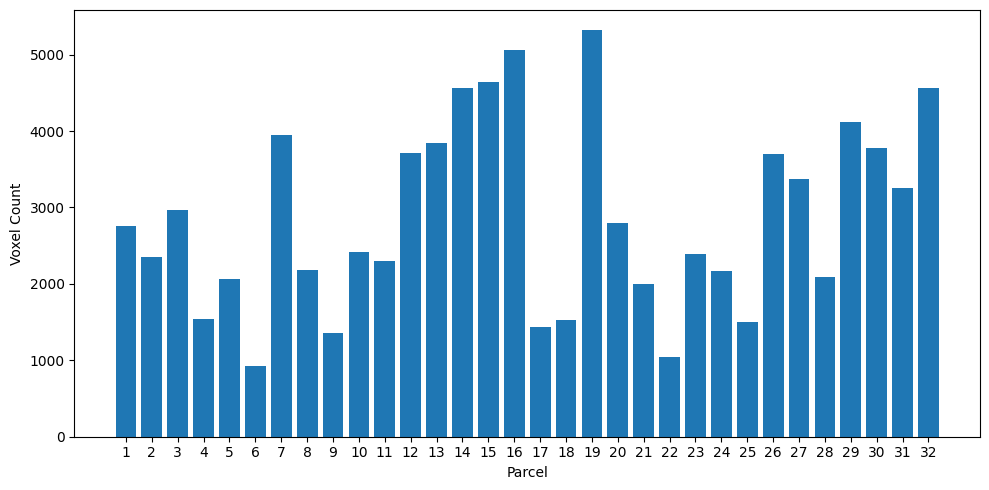

In [9]:
# make random noise data (baseline), project voxels to parcels and count voxel per parcel
data_mdtb_s1_all_noise = np.random.rand(data_mdtb_s1_all.shape[0],data_mdtb_s1_all.shape[1],data_mdtb_s1_all.shape[2])
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all_noise:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

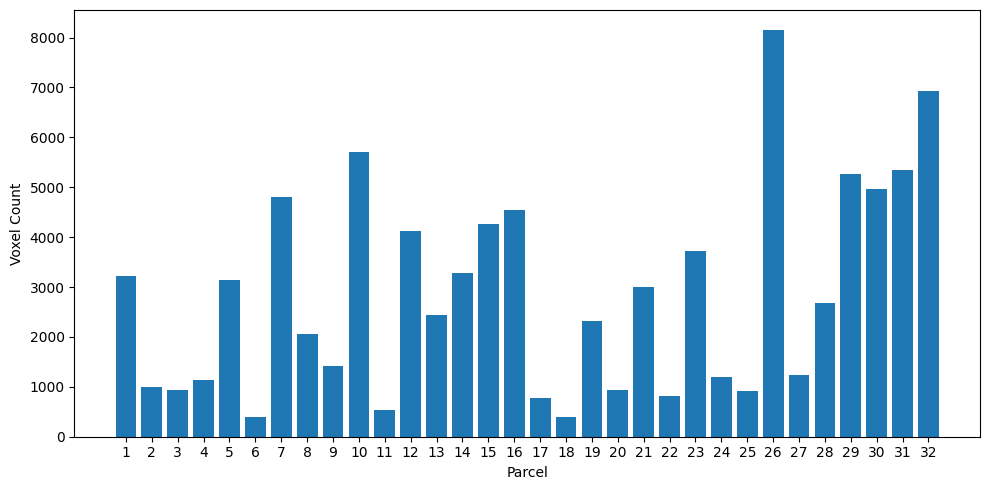

array([25, 31,  9, 30], dtype=int64)

In [11]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=range(1, 33))
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 4 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:4]
top_parcels



# subset VLib and Vtest to only include parcels with most voxels in ROI

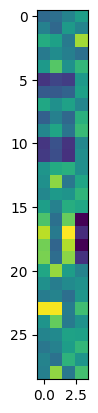

In [12]:
VLib = VL_mdtb_1[:,top_parcels]
plt.imshow(VLib)

In [15]:
vtest =  VL_mdtb_2[:,top_parcels]
vtest.shape

(32, 4)

# Get crossvalidated second moment matrix (GLib)

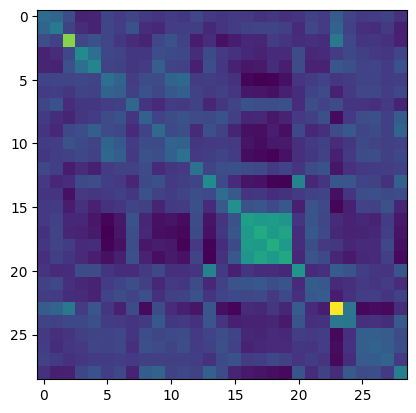

In [17]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

run evaluation on U_hats estimated using HBP framework - data only

In [83]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=400,n_tasks=8,seed=144,replacement=False)
len(D)

400

In [84]:
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)


Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300


In [24]:
# save dataframe in current repo dataframes folder
save_path = os.path.join(os.getcwd(), '..', 'dataframes')
# D_ev.to_csv(os.path.join(save_path, 'prefrontal_MDTB_s1_s2_top4parcels_8tasks.tsv'), sep='\t', index=False)
# load
D_ev = pd.read_csv(os.path.join(save_path, 'prefrontal_MDTB_s1_s2_top4parcels_4tasks.tsv'), sep='\t')

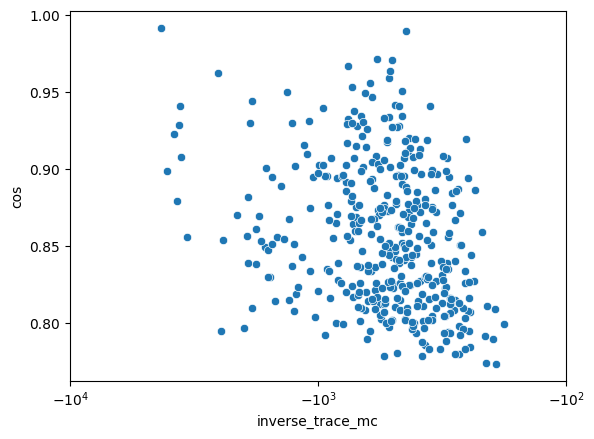

In [ ]:
sns.scatterplot(data=D_ev, x='inverse_trace_mc', y='cos')
plt.xscale('symlog', linthresh=1)
plt.xlim(-10000, -100)
plt.show()


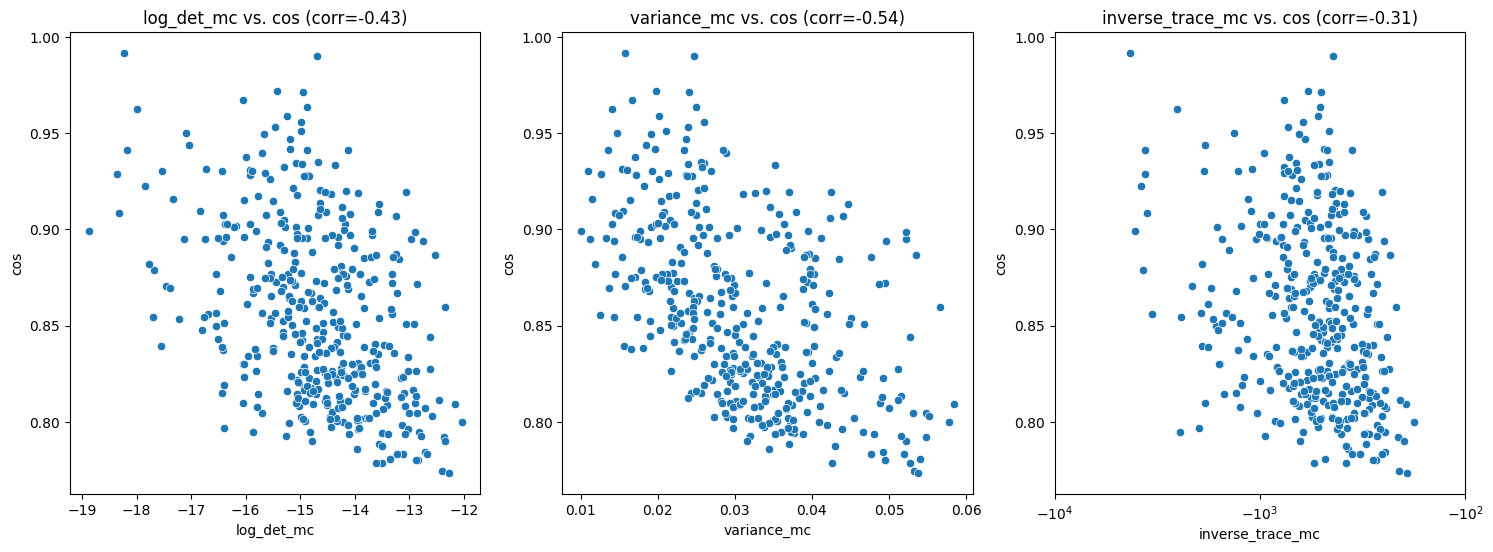

In [35]:

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=D_ev, x='log_det_mc', y='cos', ax=ax[0])
sns.scatterplot(data=D_ev, x='variance_mc', y='cos', ax=ax[1])
sns.scatterplot(data=D_ev, x='inverse_trace_mc', y='cos', ax=ax[2])
ax[2].set_xscale('symlog', linthresh=1)
ax[2].set_xlim(-10000, -100)
# add correlation values for each metric and cos
for i, metric in enumerate(['log_det_mc', 'variance_mc', 'inverse_trace_mc']):
    corr, _ = spearmanr(D_ev['cos'], D_ev[metric])
    ax[i].set_title(f'{metric} vs. cos (corr={corr:.2f})')

In [16]:
# correlation between the top 10 values of each metric and cos
for metric in ['log_det_mc', 'variance_mc', 'inverse_trace_mc']:
    top_10 = D_ev.nlargest(20, metric)
    corr, _ = spearmanr(top_10['cos'], top_10[metric])
    print(f'{metric}: {corr:.2f}')

log_det_mc: -0.03
variance_mc: -0.07
inverse_trace_mc: -0.34


In [17]:
# import pearson correlation
from scipy.stats import pearsonr
# correlation between the top 10 values of each metric and cos
for metric in ['log_det_mc', 'variance_mc', 'inverse_trace_mc']:
    top_10 = D_ev.nlargest(20, metric)
    corr, _ = pearsonr(top_10['cos'], top_10[metric])
    print(f'{metric}: {corr:.2f}')

log_det_mc: -0.07
variance_mc: -0.09
inverse_trace_mc: -0.40


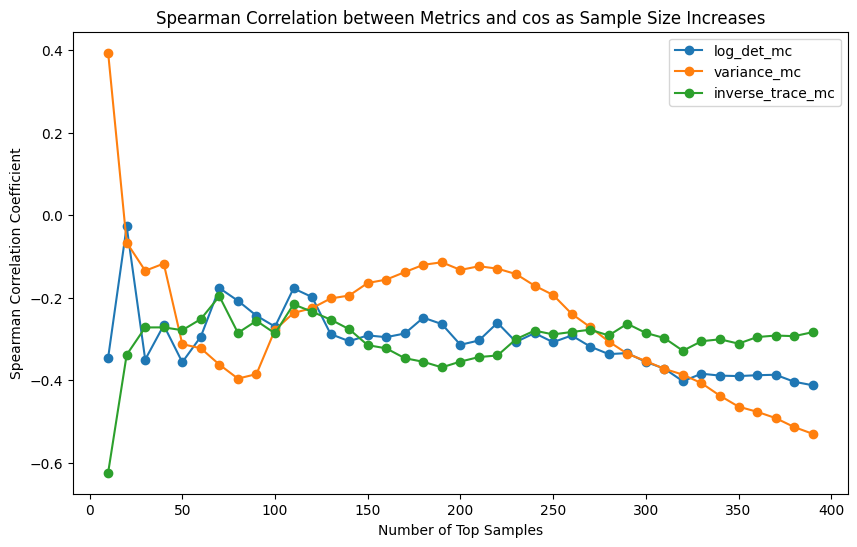

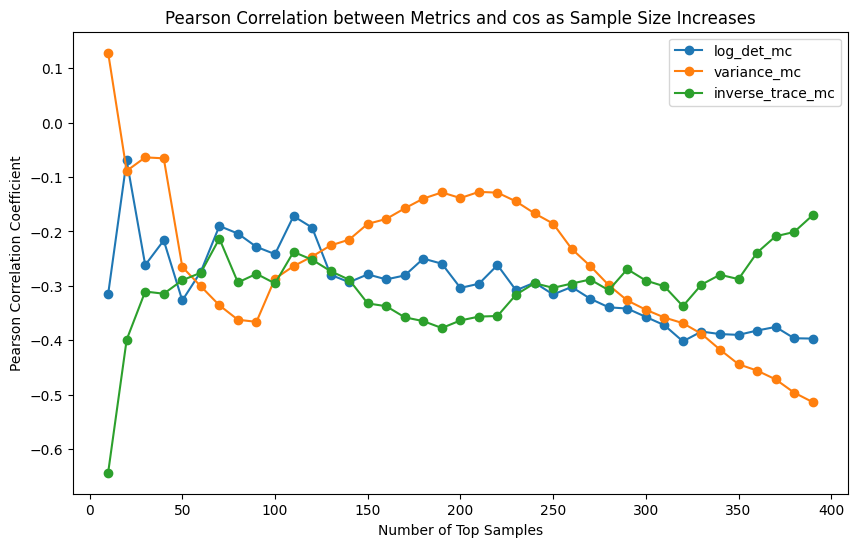

In [18]:
sample_sizes = range(10, 400, 10) 
metrics = ['log_det_mc', 'variance_mc', 'inverse_trace_mc']

correlation_data = []
for n in sample_sizes:
    for metric in metrics:
        # Get the top n samples based on the metric
        top_n = D_ev.nlargest(n, metric)
        # Compute Spearman correlation
        spearman_corr, _ = spearmanr(top_n['cos'], top_n[metric])
        # Compute Pearson correlation
        pearson_corr, _ = pearsonr(top_n['cos'], top_n[metric])
        # Store the results
        correlation_data.append({
            'Sample Size': n,
            'Metric': metric,
            'Spearman Correlation': spearman_corr,
            'Pearson Correlation': pearson_corr
        })

# Convert the list of dictionaries to a DataFrame
correlation_df = pd.DataFrame(correlation_data)

# Plotting Spearman
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['Spearman Correlation'], label=metric, marker='o')
plt.title('Spearman Correlation between Metrics and cos as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('Spearman Correlation Coefficient')
plt.legend()
plt.show()

# Plotting Pearson 
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['Pearson Correlation'], label=metric, marker='o')
plt.title('Pearson Correlation between Metrics and cos as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('Pearson Correlation Coefficient')
plt.legend()
plt.show()
